# Preconditioning high-frequency target: mode-decay check

This notebook loads `kernel_circle_preconditioning_high_frequency_target_n4096_himodes` and plots baseline/theory/empirical residual mode decay.
It is focused on verifying that preconditioning accelerates low modes while high modes outside the preconditioned block remain comparatively slow.


In [41]:
import os
import sys
from collections import defaultdict
from pathlib import Path

from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from utils.artifacts_io import latest_run_dir, load_manifest, npz


In [42]:
BASE = "../results"
EXP_NAME = "kernel_circle_preconditioning_high_frequency_target_n4096_himodes"

plot_path = Path("plots") / EXP_NAME
plot_path.mkdir(parents=True, exist_ok=True)
print("Plots will be saved to:", plot_path)

run_dir = latest_run_dir(BASE, EXP_NAME)
if run_dir is None:
    raise FileNotFoundError(f"No run found for experiment '{EXP_NAME}' in {BASE}")

manifest = load_manifest(run_dir)
probe = npz(run_dir, manifest["probe_geometry"])

print("Loaded run dir:", run_dir)
print("Available run count:", len(manifest["runs"]))
print("n_trains:", manifest["meta"]["n_trains"])
print("seeds:", manifest["meta"]["seeds"])
print("K_max (preconditioning block):", manifest["meta"]["K_max"])
print("mode_projection_k_max:", manifest["meta"].get("mode_projection_k_max", manifest["meta"]["K_max"]))


Plots will be saved to: plots/kernel_circle_preconditioning_high_frequency_target_n4096_himodes
Loaded run dir: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/kernel_circle_preconditioning_high_frequency_target_n4096_himodes/20260531-084015-1d7060f3
Available run count: 50
n_trains: [1024, 2048, 4096, 8192, 16384]
seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
K_max (preconditioning block): 8
mode_projection_k_max: 16


In [43]:
runs = {}
for run_key, rel_path in manifest["runs"].items():
    runs[run_key] = npz(run_dir, rel_path)

print("Loaded per-run files:", len(runs))


def parse_run_key(run_key: str):
    parts = run_key.split("_")
    return int(parts[1]), int(parts[3])


def unpack_run(run_key: str, arrs) -> dict:
    n, seed = parse_run_key(run_key)

    mode_names_key = "mode_names_ext" if "mode_names_ext" in arrs else "mode_names"
    mode_curves_base_key = "mode_curves_ext_base" if "mode_curves_ext_base" in arrs else "mode_curves_base"
    mode_curves_th_key = "mode_curves_ext_th" if "mode_curves_ext_th" in arrs else "mode_curves_th"
    mode_curves_emp_key = "mode_curves_ext_emp" if "mode_curves_ext_emp" in arrs else "mode_curves_emp"

    return {
        "run_key": run_key,
        "n": n,
        "seed": seed,
        "mode_names": arrs[mode_names_key],
        "mode_curves_base": arrs[mode_curves_base_key],
        "mode_curves_th": arrs[mode_curves_th_key],
        "mode_curves_emp": arrs[mode_curves_emp_key],
        "C": arrs["C"] if "C" in arrs else None,
        "C_th": arrs["C_th"] if "C_th" in arrs else None,
        "C_emp": arrs["C_emp"] if "C_emp" in arrs else None,
    }


A = {run_key: unpack_run(run_key, arrs) for run_key, arrs in runs.items()}
by_n = defaultdict(list)
for run_key, a in A.items():
    by_n[a["n"]].append(a)

for n in sorted(by_n):
    seeds = sorted(x["seed"] for x in by_n[n])
    print(f"n={n:4d}  runs={len(by_n[n])}  seeds={seeds}")


Loaded per-run files: 50
n=1024  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n=2048  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n=4096  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n=8192  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n=16384  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


Using run: n=4096, seed=0
Available mode count: 33
Modes plotted: ['const', 'cos_1', 'cos_2', 'sin_3', 'cos_7', 'sin_10', 'cos_12']
Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_n4096_himodes/mode_curve_compare_const_n4096_seed0.png


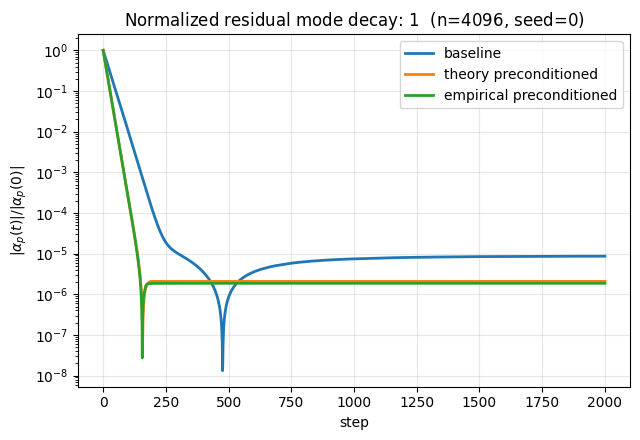

Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_n4096_himodes/mode_curve_compare_cos_1_n4096_seed0.png


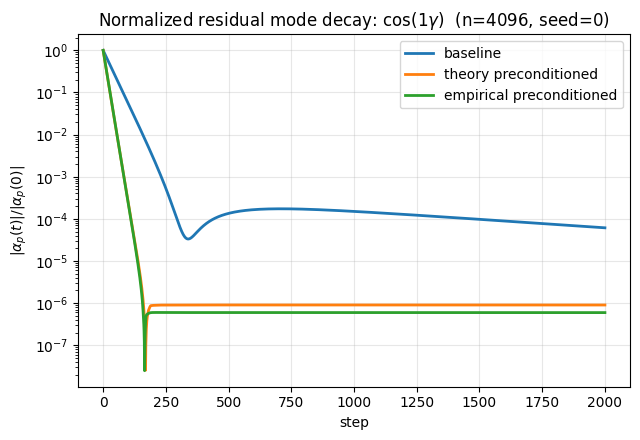

Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_n4096_himodes/mode_curve_compare_cos_2_n4096_seed0.png


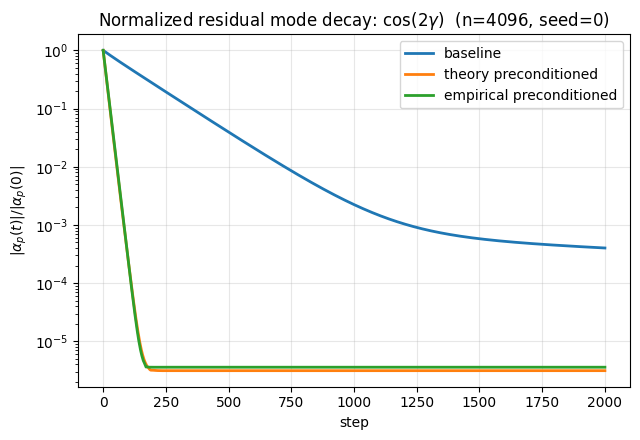

Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_n4096_himodes/mode_curve_compare_sin_3_n4096_seed0.png


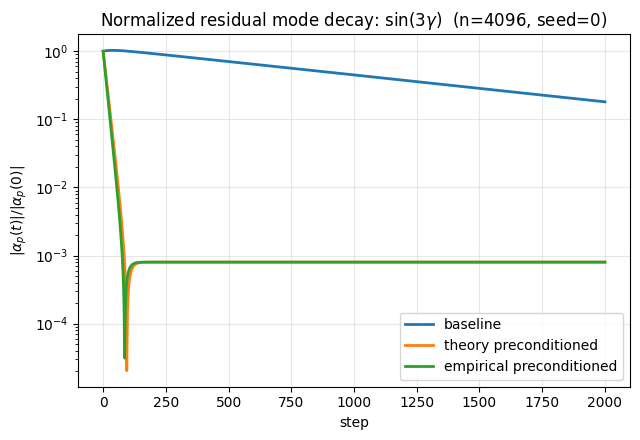

Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_n4096_himodes/mode_curve_compare_cos_7_n4096_seed0.png


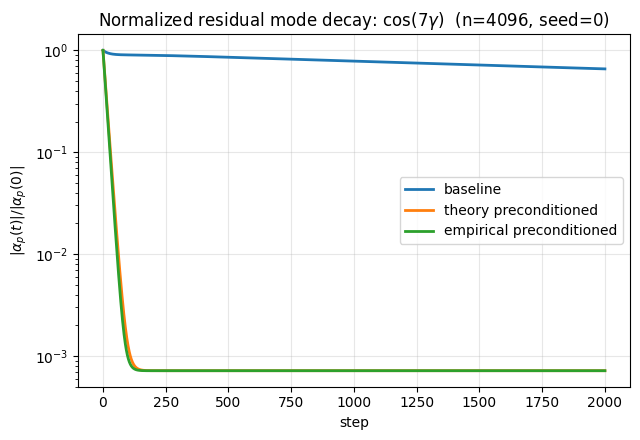

Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_n4096_himodes/mode_curve_compare_sin_10_n4096_seed0.png


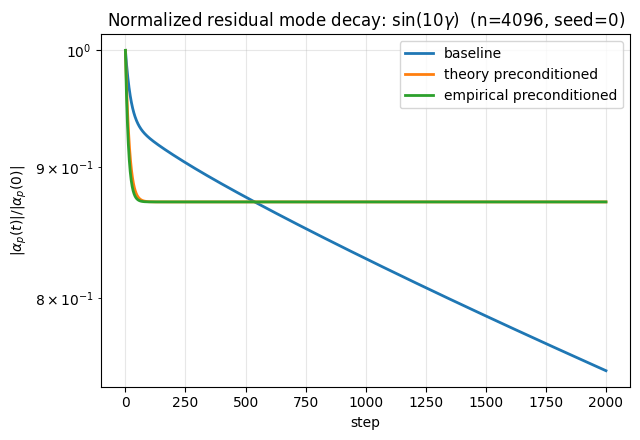

Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_n4096_himodes/mode_curve_compare_cos_12_n4096_seed0.png


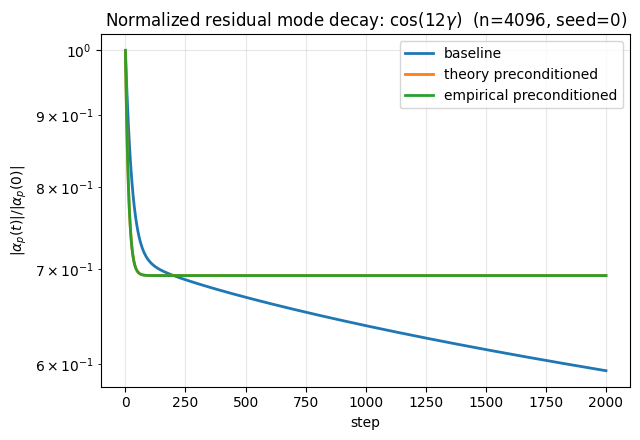

In [59]:
def _decode_name(x):
    if isinstance(x, bytes):
        return x.decode("utf-8")
    return str(x)


def _as_time_mode(arr, d_expected):
    arr = np.asarray(arr)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {arr.shape}")
    if arr.shape[1] == d_expected:
        return arr
    if arr.shape[0] == d_expected:
        return arr.T
    raise ValueError(f"Cannot interpret array with shape {arr.shape} and d_expected={d_expected}")


def component_label(mode_name: str) -> str:
    if mode_name == "const":
        return r"$1$"
    if mode_name.startswith("cos_"):
        k = mode_name.split("_", 1)[1]
        return rf"$\cos({k}\gamma)$"
    if mode_name.startswith("sin_"):
        k = mode_name.split("_", 1)[1]
        return rf"$\sin({k}\gamma)$"
    return mode_name


n_show = 4096 # max(by_n.keys())
seed_show = sorted(x["seed"] for x in by_n[n_show])[0]
run = next(x for x in by_n[n_show] if x["seed"] == seed_show)

mode_names = [_decode_name(x) for x in run["mode_names"]]
name_to_idx = {name: i for i, name in enumerate(mode_names)}
d = len(mode_names)

curves_base = _as_time_mode(run["mode_curves_base"], d)
curves_th = _as_time_mode(run["mode_curves_th"], d)
curves_emp = _as_time_mode(run["mode_curves_emp"], d)
steps = np.arange(curves_base.shape[0])

modes_to_plot = ["const", "cos_1", "cos_2", "sin_3", "cos_7", "sin_10", "cos_12"]
modes_to_plot = [m for m in modes_to_plot if m in name_to_idx]

print(f"Using run: n={n_show}, seed={seed_show}")
print("Available mode count:", d)
print("Modes plotted:", modes_to_plot)

for mode_name in modes_to_plot:
    j = name_to_idx[mode_name]

    plt.figure(figsize=(6.5, 4.5))
    plt.plot(steps, curves_base[:, j], linewidth=2, label="baseline")
    plt.plot(steps, curves_th[:, j], linewidth=2, label="theory preconditioned")
    plt.plot(steps, curves_emp[:, j], linewidth=2, label="empirical preconditioned")

    plt.yscale("log")
    plt.xlabel("step")
    plt.ylabel(r"$|\alpha_p(t)| / |\alpha_p(0)|$")
    plt.title(
        f"Normalized residual mode decay: {component_label(mode_name)}  (n={n_show}, seed={seed_show})"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    filename = plot_path / f"mode_curve_compare_{mode_name}_n{n_show}_seed{seed_show}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Successfully saved {filename}")
    plt.show()


Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_n4096_himodes/out_of_block_all_mode_decay_three_panel_mean_std_n4096.png


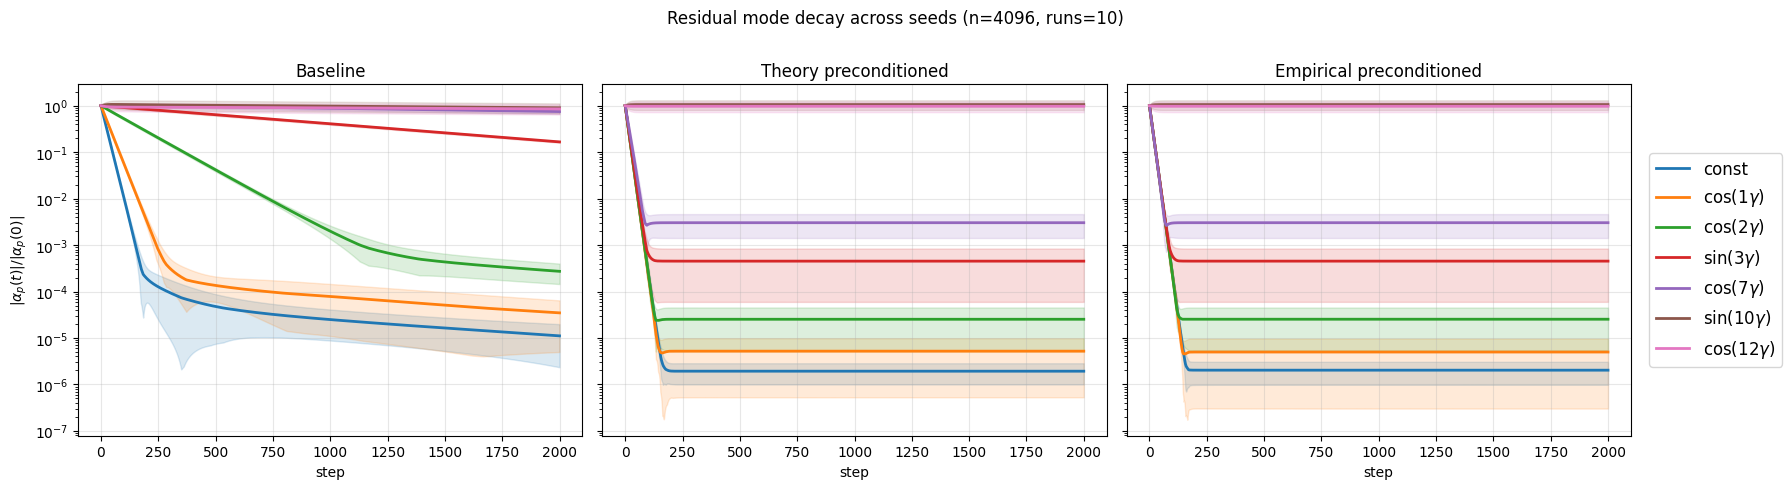

In [62]:
def stack_curves_for_n(by_n, n, key):
    runs_n = by_n[n]
    mode_names = [_decode_name(x) for x in runs_n[0]["mode_names"]]
    d = len(mode_names)
    mats = [_as_time_mode(run[key], d) for run in runs_n]
    return mode_names, np.stack(mats, axis=0)


mode_names, base_stack = stack_curves_for_n(by_n, n_show, "mode_curves_base")
_, th_stack = stack_curves_for_n(by_n, n_show, "mode_curves_th")
_, emp_stack = stack_curves_for_n(by_n, n_show, "mode_curves_emp")

steps = np.arange(base_stack.shape[1])
curve_sets = [
    ("Baseline", base_stack),
    ("Theory preconditioned", th_stack),
    ("Empirical preconditioned", emp_stack),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True, sharey=True)
mode_handles = []
for ax, (title, stack) in zip(axes, curve_sets):
    mean = stack.mean(axis=0)
    std = stack.std(axis=0)

    for mode_pos, mode_name in enumerate(modes_to_plot):
        j = mode_names.index(mode_name)
        color = plt.cm.tab10(mode_pos % 10)
        ax.plot(steps, mean[:, j], linewidth=2, color=color)
        lower = np.clip(mean[:, j] - std[:, j], 1e-10, None)
        upper = np.clip(mean[:, j] + std[:, j], 1e-10, None)
        ax.fill_between(steps, lower, upper, color=color, alpha=0.16)
        if ax is axes[0]:
            mode_handles.append(
                Line2D([], [], color=color, linewidth=2, label=mode_name if mode_name=="const" else component_label(mode_name))
            )

    ax.set_yscale("log")
    ax.set_xlabel("step")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"$|\alpha_p(t)| / |\alpha_p(0)|$")
axes[-1].legend(handles=mode_handles, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=12)

fig.suptitle(f"Residual mode decay across seeds (n={n_show}, runs={len(by_n[n_show])})", y=1.01)
fig.tight_layout()

filename = plot_path / f"out_of_block_all_mode_decay_three_panel_mean_std_n{n_show}.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Successfully saved {filename}")
plt.show()

Loaded x64 run dir: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/kernel_circle_preconditioning_high_frequency_target_n4096_himodes_x64/20260531-110816-068dcd5a
Successfully saved plots/kernel_circle_preconditioning_high_frequency_target_n4096_himodes/all_mode_decay_three_panel_mean_std_fp32_vs_fp64_n4096.png


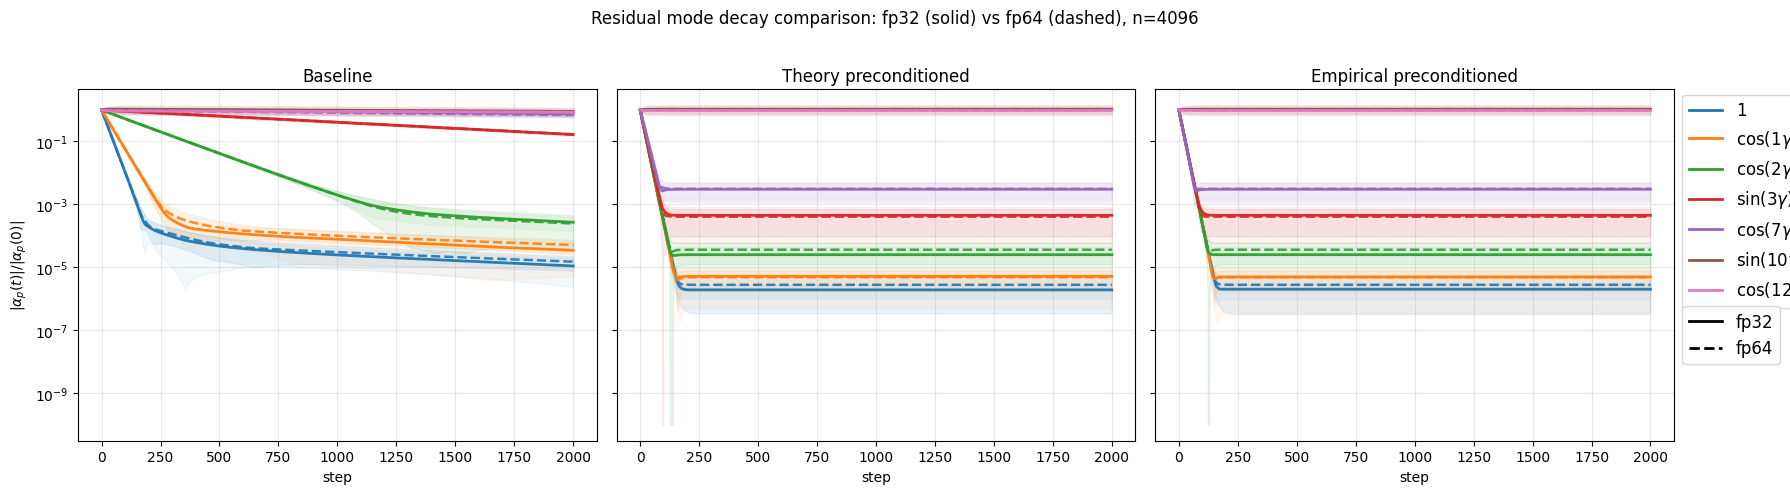

In [61]:
EXP_NAME_X64 = EXP_NAME + "_x64"
run_dir_x64 = latest_run_dir(BASE, EXP_NAME_X64)
if run_dir_x64 is None:
    raise FileNotFoundError(f"No run found for experiment '{EXP_NAME_X64}' in {BASE}")

manifest_x64 = load_manifest(run_dir_x64)
runs_x64 = {}
for run_key, rel_path in manifest_x64["runs"].items():
    runs_x64[run_key] = npz(run_dir_x64, rel_path)

A_x64 = {run_key: unpack_run(run_key, arrs) for run_key, arrs in runs_x64.items()}
by_n_x64 = defaultdict(list)
for run_key, a in A_x64.items():
    by_n_x64[a["n"]].append(a)

if n_show not in by_n_x64:
    raise ValueError(f"n_show={n_show} not present in x64 results")

mode_names_64, base_stack_64 = stack_curves_for_n(by_n_x64, n_show, "mode_curves_base")
_, th_stack_64 = stack_curves_for_n(by_n_x64, n_show, "mode_curves_th")
_, emp_stack_64 = stack_curves_for_n(by_n_x64, n_show, "mode_curves_emp")

curve_sets_32 = {
    "mode_curves_base": base_stack,
    "mode_curves_th": th_stack,
    "mode_curves_emp": emp_stack,
}
curve_sets_64 = {
    "mode_curves_base": base_stack_64,
    "mode_curves_th": th_stack_64,
    "mode_curves_emp": emp_stack_64,
}

idx32 = {name: i for i, name in enumerate(mode_names)}
idx64 = {name: i for i, name in enumerate(mode_names_64)}
plot_modes = [m for m in modes_to_plot if m in idx32 and m in idx64]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True, sharey=True)
compare_sets = [
    ("Baseline", "mode_curves_base"),
    ("Theory preconditioned", "mode_curves_th"),
    ("Empirical preconditioned", "mode_curves_emp"),
]

mode_handles = []
for ax, (title, key) in zip(axes, compare_sets):
    s32 = curve_sets_32[key]
    s64 = curve_sets_64[key]

    T = min(s32.shape[1], s64.shape[1])
    steps_cmp = np.arange(T)

    mean32 = s32[:, :T, :].mean(axis=0)
    std32 = s32[:, :T, :].std(axis=0)
    mean64 = s64[:, :T, :].mean(axis=0)
    std64 = s64[:, :T, :].std(axis=0)

    for mode_pos, mode_name in enumerate(plot_modes):
        j32 = idx32[mode_name]
        j64 = idx64[mode_name]
        color = plt.cm.tab10(mode_pos % 10)

        ax.plot(
            steps_cmp,
            mean32[:, j32],
            linestyle="-",
            linewidth=2.0,
            color=color,
            alpha=0.95,
        )
        ax.fill_between(
            steps_cmp,
            np.clip(mean32[:, j32] - std32[:, j32], 1e-10, None),
            np.clip(mean32[:, j32] + std32[:, j32], 1e-10, None),
            color=color,
            alpha=0.05,
        )

        ax.plot(
            steps_cmp,
            mean64[:, j64],
            linestyle="--",
            linewidth=1.8,
            color=color,
            alpha=0.9,
        )
        ax.fill_between(
            steps_cmp,
            np.clip(mean64[:, j64] - std64[:, j64], 1e-10, None),
            np.clip(mean64[:, j64] + std64[:, j64], 1e-10, None),
            color=color,
            alpha=0.09,
        )

        if ax is axes[0]:
            mode_handles.append(
                Line2D([], [], color=color, linewidth=2, label=component_label(mode_name))
            )

    ax.set_yscale("log")
    ax.set_xlabel("step")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"$|\alpha_p(t)| / |\alpha_p(0)|$")
mode_legend = axes[-1].legend(
    handles=mode_handles,
    loc="center left",
    bbox_to_anchor=(1.0, 0.68),
    fontsize=12,
)
axes[-1].add_artist(mode_legend)

style_handles = [
    Line2D([], [], color="black", linestyle="-", linewidth=2, label="fp32"),
    Line2D([], [], color="black", linestyle="--", linewidth=2, label="fp64"),
]
axes[-1].legend(
    handles=style_handles,
    loc="center left",
    bbox_to_anchor=(1.0, 0.30),
    fontsize=12,
)

fig.suptitle(
    f"Residual mode decay comparison: fp32 (solid) vs fp64 (dashed), n={n_show}",
    y=1.02,
)
fig.tight_layout()

filename = plot_path / f"all_mode_decay_three_panel_mean_std_fp32_vs_fp64_n{n_show}.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
print("Loaded x64 run dir:", run_dir_x64)
print(f"Successfully saved {filename}")
plt.show()


In [55]:
def _safe_cond_from_matrix(M, eps=1e-14):
    M = np.asarray(M, dtype=float)
    eigs = np.real(np.linalg.eigvals(M))
    eigs = eigs[np.isfinite(eigs)]
    if eigs.size == 0:
        return np.nan
    lam_max = np.max(eigs)
    lam_min = np.min(eigs)
    if lam_min <= eps:
        return np.inf
    return lam_max / lam_min


def _summary(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.nan, np.nan, np.nan
    return float(np.mean(vals)), float(np.median(vals)), float(np.quantile(vals, 0.90))


def _fmt(x):
    if np.isnan(x):
        return "nan"
    if np.isinf(x):
        return "inf"
    return f"{x:.3e}"


eps32 = np.finfo(np.float32).eps
eps64 = np.finfo(np.float64).eps

rows = []
for n in sorted(by_n.keys()):
    runs_n = by_n[n]

    cond_C = []
    cond_Cth = []
    cond_Cemp = []

    for run in runs_n:
        if run["C"] is None or run["C_th"] is None or run["C_emp"] is None:
            continue
        cond_C.append(_safe_cond_from_matrix(run["C"]))
        cond_Cth.append(_safe_cond_from_matrix(run["C_th"]))
        cond_Cemp.append(_safe_cond_from_matrix(run["C_emp"]))

    C_mean, C_med, C_q90 = _summary(cond_C)
    Cth_mean, Cth_med, Cth_q90 = _summary(cond_Cth)
    Cemp_mean, Cemp_med, Cemp_q90 = _summary(cond_Cemp)

    fp32_floor = Cth_med * eps32 if np.isfinite(Cth_med) else np.nan
    fp64_floor = Cth_med * eps64 if np.isfinite(Cth_med) else np.nan

    rows.append(
        {
            "n": int(n),
            "runs": len(cond_Cth),
            "C_mean": C_mean,
            "Cth_mean": Cth_mean,
            "Cemp_mean": Cemp_mean,
            "Cth_med": Cth_med,
            "Cth_q90": Cth_q90,
            "fp32_floor": fp32_floor,
            "fp64_floor": fp64_floor,
        }
    )

header = (
    f"{'n':>7} {'runs':>5} "
    f"{'cond(C)_mean':>14} {'cond(C_th)_mean':>17} {'cond(C_emp)_mean':>18} "
    f"{'cond(C_th)_med':>16} {'cond(C_th)_q90':>16} "
    f"{'fp32_floor~k*u':>16} {'fp64_floor~k*u':>16}"
)
print(header)
print('-' * len(header))
for r in rows:
    print(
        f"{r['n']:7d} {r['runs']:5d} "
        f"{_fmt(r['C_mean']):>14} {_fmt(r['Cth_mean']):>17} {_fmt(r['Cemp_mean']):>18} "
        f"{_fmt(r['Cth_med']):>16} {_fmt(r['Cth_q90']):>16} "
        f"{_fmt(r['fp32_floor']):>16} {_fmt(r['fp64_floor']):>16}"
    )

print("\nNote: floor columns are heuristic relative-error floors ~ cond(C_th)_median * machine epsilon.")


      n  runs   cond(C)_mean   cond(C_th)_mean   cond(C_emp)_mean   cond(C_th)_med   cond(C_th)_q90   fp32_floor~k*u   fp64_floor~k*u
-------------------------------------------------------------------------------------------------------------------------------------
   1024    10      3.408e+02         2.273e+00          1.000e+00        2.249e+00        2.396e+00        2.681e-07        4.993e-16
   2048    10      3.334e+02         1.644e+00          1.000e+00        1.633e+00        1.710e+00        1.947e-07        3.626e-16
   4096    10      3.295e+02         1.364e+00          1.000e+00        1.349e+00        1.433e+00        1.608e-07        2.996e-16
   8192    10      3.286e+02         1.220e+00          1.000e+00        1.209e+00        1.249e+00        1.441e-07        2.685e-16
  16384    10      3.271e+02         1.142e+00          1.000e+00        1.139e+00        1.176e+00        1.358e-07        2.529e-16

Note: floor columns are heuristic relative-error floors ~ con